>what's a black hole's favourite meal? spaghetti.

(this will make sense soon, if it doesn't already)

for a radial fall, the geodesic equation collapses into,

$$\frac{d^2r}{d\tau^2} = -\frac{M}{r^2}$$

it's newton's equation!!!!!!! haiii~~~

note here, though, the clock $\tau$ is the wristwatch time.

my distant friend, watching from a space ship in miller's planet measures the coordinate time $t$ instead, related by $dt/d\tau = E/(1 - 2M/r)$ and the denominator goes to zero at the horizon. 

let's integrate the fall once, cleanly, and then read off both clocks.

In [2]:
import numpy as np
from scipy.integrate import solve_ivp, cumulative_trapezoid
import matplotlib.pyplot as plt

# geometrized units
M = 1.0    
# where we let go                  
r0 = 10.0          
# conserved energy for a fall from rest at r0          
E = np.sqrt(1 - 2*M/r0)      

plt.rcParams['figure.dpi'] = 110

# newton's equation, einstein's clock
def rhs(tau, y):
    r, rdot = y
    return [rdot, -M/r**2]

 # stop just shy of r = 0
stop = lambda t, y: y[0] - 1e-4         
stop.terminal = True
sol = solve_ivp(rhs, (0, 50), [r0, 0.0], events=stop,
                rtol=1e-12, atol=1e-14, dense_output=True)

tau  = np.linspace(0, sol.t[-1], 6000)
r, rdot = sol.sol(tau)

# my friend's clock only meaningful outside the horizon
out   = r > 2*M + 1e-3
t_out = cumulative_trapezoid(E/(1 - 2*M/r[out]), tau[out], initial=0)

print(f"proper time from r = 10M to the singularity: tau = {sol.t[-1]:.2f} M")
print(f"(analytic cycloid result: pi*sqrt(r0^3/8M)  = {np.pi*np.sqrt(r0**3/8):.2f} M)")

proper time from r = 10M to the singularity: tau = 35.12 M
(analytic cycloid result: pi*sqrt(r0^3/8M)  = 35.12 M)


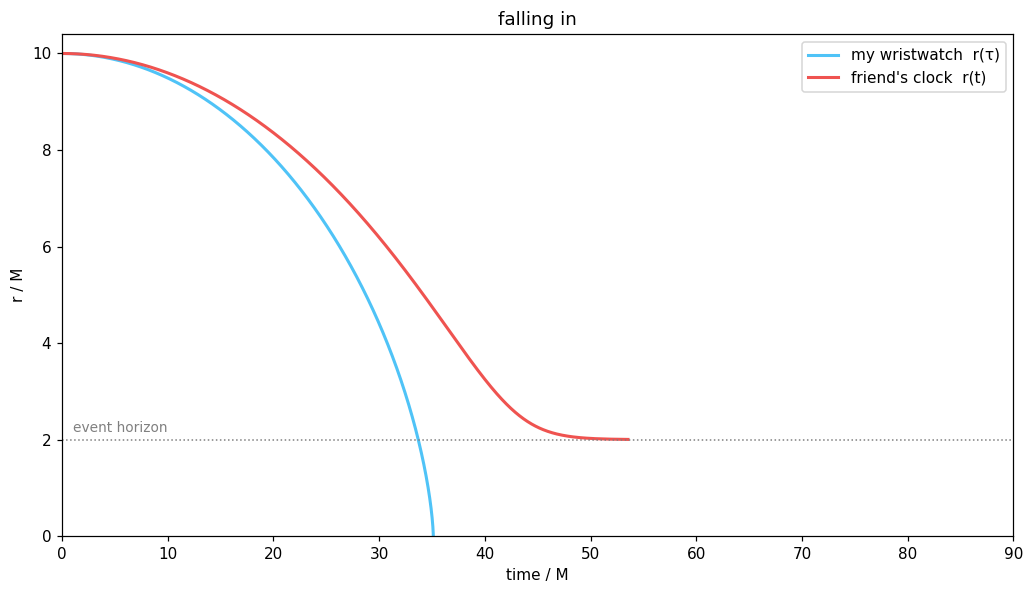

In [4]:
plt.figure(figsize=(9.5, 5.5))
plt.plot(tau, r, color='#4fc3f7', lw=2, label='my wristwatch  r(τ)')
plt.plot(t_out, r[out], color='#ef5350', lw=2, label="friend's clock  r(t)")
plt.axhline(2*M, color='gray', ls=':', lw=1)
plt.text(1, 2.15, 'event horizon', color='gray', fontsize=9)
plt.xlim(0, 90); plt.ylim(0, 10.4)
plt.xlabel('time / M'); plt.ylabel('r / M')
plt.title('falling in')
plt.legend()
plt.tight_layout(); plt.show()

one fall here, but there's two stories

my story is the one in blue. 

In [5]:
# seconds per solar mass (GM/c^3)
GM_c3 = 4.9255e-6      
tau_fall = sol.t[-1]

for name, msun in [("a 10 solar-mass black hole", 10), ("sagittarius a* (4.3 million suns)", 4.3e6)]:
    secs = tau_fall * GM_c3 * msun
    nice = f"{secs*1e3:.1f} milliseconds" if secs < 1 else f"{secs/60:.1f} minutes"
    print(f"falling from 10M into {name}: {nice}")

falling from 10M into a 10 solar-mass black hole: 1.7 milliseconds
falling from 10M into sagittarius a* (4.3 million suns): 12.4 minutes
